In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-01.csv
/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-03.csv
/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-02.csv
/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2015-01.csv


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
spark = SparkSession.builder \
    .appName("NYC Yellow Taxi EDA") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

In [10]:
df = spark.read.csv(
    '/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-01.csv',
    header=True,
    inferSchema=True
)

In [11]:
df.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude  |pickup_latitude   |RatecodeID|store_and_fwd_flag|dropoff_longitude |dropoff_latitude  |payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|2       |2016-01-01 00:00:00 |2016-01-01 00:00:00  |2              |1.1          |-73.99037170410156|40.73469543457031 |1         |N   

In [12]:

df.limit(5).toPandas()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01,2016-01-01,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01,2016-01-01,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01,2016-01-01,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01,2016-01-01,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01,2016-01-01,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


In [14]:
print("Number of Rows:", df.count())
print("Number of Columns:", len(df.columns))

Number of Rows: 10906858
Number of Columns: 19


In [15]:
print(df.columns)

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [19]:
df.describe().show()

+-------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+
|summary|           VendorID|   passenger_count|     trip_distance|   pickup_longitude|   pickup_latitude|        RatecodeID|store_and_fwd_flag|  dropoff_longitude|  dropoff_latitude|      payment_type|       fare_amount|             extra|            mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|
+-------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+---------------------+

In [23]:

df.describe().toPandas()


,summary,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,count,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858,10906858
1,mean,1.5350238354620551,1.670846819496504,4.648196988536868,-72.81869455769787,40.11494259107597,1.0393496458833515,None,-72.88659117441934,40.15315229928887,1.3475360181639846,12.486929470430423,0.3130756896257383,0.4976704592651706,1.7506631158121155,0.2933452622194928,0.29972446051382845,15.641395247926114
2,stddev,0.49877184539468683,1.3248907816769706,2981.0953288423316,9.168964159535648,5.0510224326758655,0.5186309162351989,None,8.900841453884862,4.90345587068521,0.4910804464319991,35.56400378933263,0.4156791924614062,0.05046685412593845,2.623545826135015,1.6945719541113626,0.01232553373567381,36.41280207334372
3,min,1,0.0,0.0,-121.93428802490234,0.0,1,N,-121.93348693847656,0.0,1,-957.6,-42.61,-0.5,-220.8,-17.4,-0.3,-958.4
4,max,2,9.0,8000010.0,0.0,60.908756256103516,99,Y,0.0,60.908756256103516,5,111270.85,648.87,89.7,998.14,980.15,0.3,111271.65


In [20]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude|pickup_latitude|RatecodeID|store_and_fwd_flag|dropoff_longitude|dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       0|                   0|                    0|              0|            0|               0|              0|         0|                 0|              

In [17]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)



In [21]:
total_rows = df.count()
unique_rows = df.dropDuplicates().count()

print("Total Rows:", total_rows)
print("Unique Rows:", unique_rows)
print("Duplicate Rows:", total_rows - unique_rows)

Total Rows: 10906858
Unique Rows: 10906857
Duplicate Rows: 1


In [31]:
from pyspark.sql.functions import unix_timestamp, round


df_with_duration = df.withColumn(
    "duration_minutes", 
    round((unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60, 2)
)


df_cleaned = df_with_duration.filter(
    (df_with_duration.trip_distance > 0) & (df_with_duration.trip_distance < 100) & 
    (df_with_duration.fare_amount > 0) & (df_with_duration.fare_amount < 500) &
    (df_with_duration.passenger_count > 0) & (df_with_duration.passenger_count <= 6) &
    (df_with_duration.total_amount > 0) &
    (df_with_duration.duration_minutes >= 1)
)


print(f"num of rows before clean: {df.count()}")
print(f"num of rows after clean : {df_cleaned.count()}")


df_cleaned.select("trip_distance", "duration_minutes", "fare_amount", "total_amount").describe().show()


num of rows before clean: 10906858


num of rows after clean : 10803240


+-------+------------------+------------------+------------------+------------------+
|summary|     trip_distance|  duration_minutes|       fare_amount|      total_amount|
+-------+------------------+------------------+------------------+------------------+
|  count|          10803240|          10803240|          10803240|          10803240|
|   mean| 2.919242362476449|15.385790835897179|12.431943959404764|15.580867452815273|
| stddev|3.6049211498361458| 87.21125447906907|10.412513112245708|12.899082050382054|
|    min|              0.01|               1.0|              0.01|              0.31|
|    max|              99.3|          119912.7|             480.0|           1015.95|
+-------+------------------+------------------+------------------+------------------+



In [32]:
from pyspark.sql.functions import hour, dayofweek, month

df_with_time = df_cleaned.withColumn("hour", hour("tpep_pickup_datetime")) \
                         .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) \
                         .withColumn("month", month("tpep_pickup_datetime"))

peak_hours = df_with_time.groupBy("hour").count().orderBy("hour")

peak_hours_pd = peak_hours.toPandas()
print(peak_hours_pd)


    hour   count
0      0  391210
1      1  296254
2      2  225850
3      3  166075
4      4  122681
5      5  109060
6      6  233091
7      7  400903
8      8  487715
9      9  488059
10    10  476788
11    11  498568
12    12  530998
13    13  527249
14    14  557629
15    15  558576
16    16  506047
17    17  586471
18    18  686660
19    19  677737
20    20  619408
21    21  603120
22    22  576366
23    23  476725


/tmp/ipykernel_57/1923549679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hour", y="count", data=peak_hours_pd, palette="viridis")


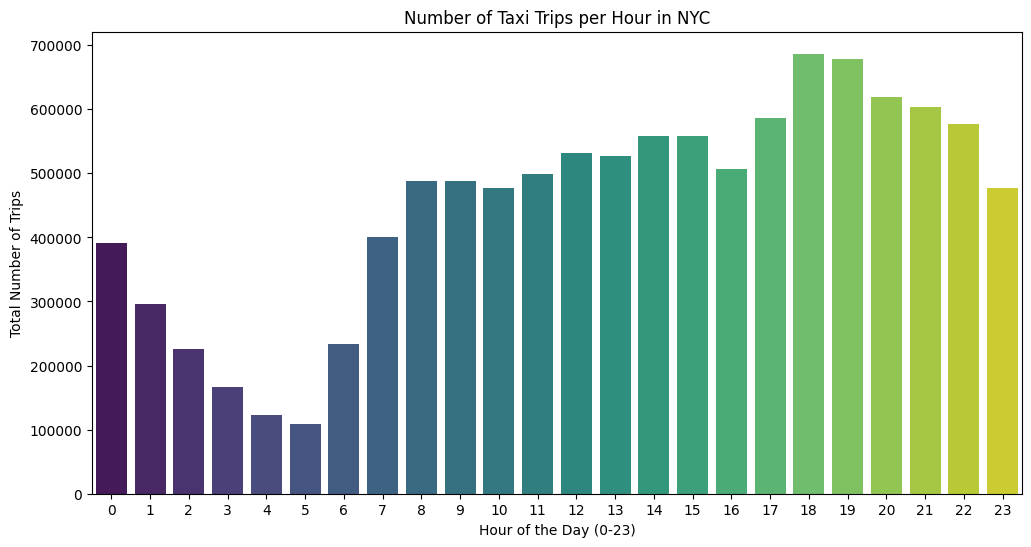

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x="hour", y="count", data=peak_hours_pd, palette="viridis")
plt.title("Number of Taxi Trips per Hour in NYC")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Total Number of Trips")
plt.show()


  day_name    count
1      Mon  1269132
6      Tue  1410244
5      Wed  1471618
4      Thu  1530719
3      Fri  1953929
2      Sat  1628416
0      Sun  1539182


/tmp/ipykernel_57/1310369978.py:25: FutureWarning:                              

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="day_name", y="count", data=day_analysis_pd, palette="magma")


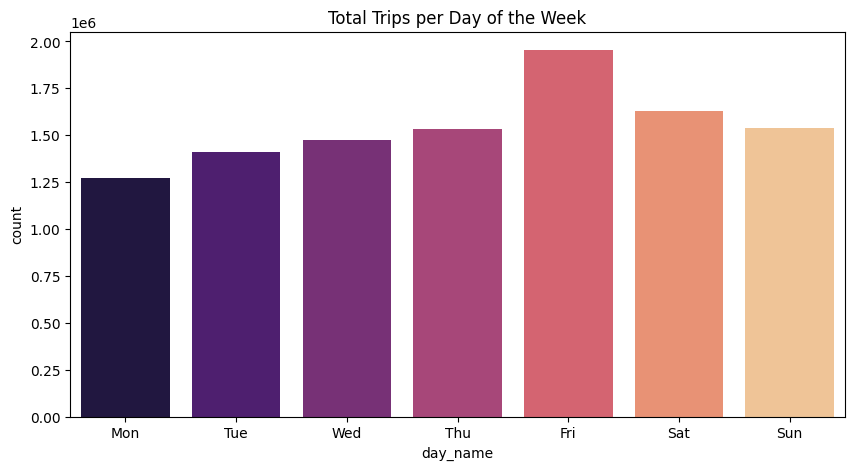

In [34]:
from pyspark.sql.functions import date_format

day_analysis = df_with_time.groupBy(date_format("tpep_pickup_datetime", "E").alias("day_name")).count()

days_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

day_analysis_pd = day_analysis.toPandas()


day_analysis_pd['day_name'] = pd.Categorical(day_analysis_pd['day_name'], categories=days_order, ordered=True)
day_analysis_pd = day_analysis_pd.sort_values('day_name')

print(day_analysis_pd)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x="day_name", y="count", data=day_analysis_pd, palette="magma")
plt.title("Total Trips per Day of the Week")
plt.show()


In [35]:
from pyspark.sql.functions import unix_timestamp, round

df_with_duration = df_with_time.withColumn(
    "duration_minutes", 
    round((unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60, 2)
)

df_duration_cleaned = df_with_duration.filter((df_with_duration.duration_minutes > 0) & (df_with_duration.duration_minutes < 240))

df_duration_cleaned.select("trip_distance", "duration_minutes").describe().show()


+-------+------------------+------------------+
|summary|     trip_distance|  duration_minutes|
+-------+------------------+------------------+
|  count|          10786708|          10786708|
|   mean|2.9182260148323333|13.261680671248158|
| stddev|3.6022154667193353|10.264142422065078|
|    min|              0.01|               1.0|
|    max|             99.16|             239.7|
+-------+------------------+------------------+



In [36]:
from pyspark.sql.functions import when, col

df_financial = df_cleaned.withColumn("payment_method", 
    when(col("payment_type") == 1, "Credit Card")
    .when(col("payment_type") == 2, "Cash")
    .otherwise("Other")
)

payment_analysis = df_financial.groupBy("payment_method").agg(
    {"*": "count", "total_amount": "sum", "tip_amount": "avg"}
).orderBy("count(1)", ascending=False)

payment_analysis.show()


+--------------+--------------------+--------+--------------------+
|payment_method|   sum(total_amount)|count(1)|     avg(tip_amount)|
+--------------+--------------------+--------+--------------------+
|   Credit Card|1.2138859528989081E8| 7145055|  2.6382860537812736|
|          Cash|4.6360421319794275E7| 3623301|1.045676304563159...|
|         Other|   574833.8900000214|   34884|0.020717520926499252|
+--------------+--------------------+--------+--------------------+



In [37]:

trip_type_tips = df_financial.withColumn("trip_category", 
    when(col("RatecodeID") == 2, "JFK Airport")
    .otherwise("Standard City Trip")
)

tip_stats = trip_type_tips.groupBy("trip_category").agg(
    {"tip_amount": "avg", "fare_amount": "avg", "total_amount": "mean"}
)

tip_stats.toPandas()


,trip_category,avg(fare_amount),avg(total_amount),avg(tip_amount)
0,Standard City Trip,11.631431,14.589086,1.631024
1,JFK Airport,51.984650,64.583967,7.377128


In [42]:
from pyspark.sql.functions import round as spark_round

hotspots = df_cleaned.groupBy(
    spark_round("pickup_longitude", 3).alias("lat"),
    spark_round("pickup_latitude", 3).alias("long")
).count().orderBy("count", ascending=False)

top_10_hotspots = hotspots.limit(10).toPandas()

print("--- Top 10 Pickup Hotspots in NYC ---")
print(top_10_hotspots)



--- Top 10 Pickup Hotspots in NYC ---
      lat    long   count
0   0.000   0.000  155832
1 -73.994  40.751   62439
2 -73.991  40.750   57793
3 -73.782  40.645   54030
4 -73.871  40.774   48340
5 -73.873  40.774   47649
6 -73.992  40.750   44169
7 -73.777  40.645   38875
8 -73.863  40.769   37611
9 -73.864  40.770   32753


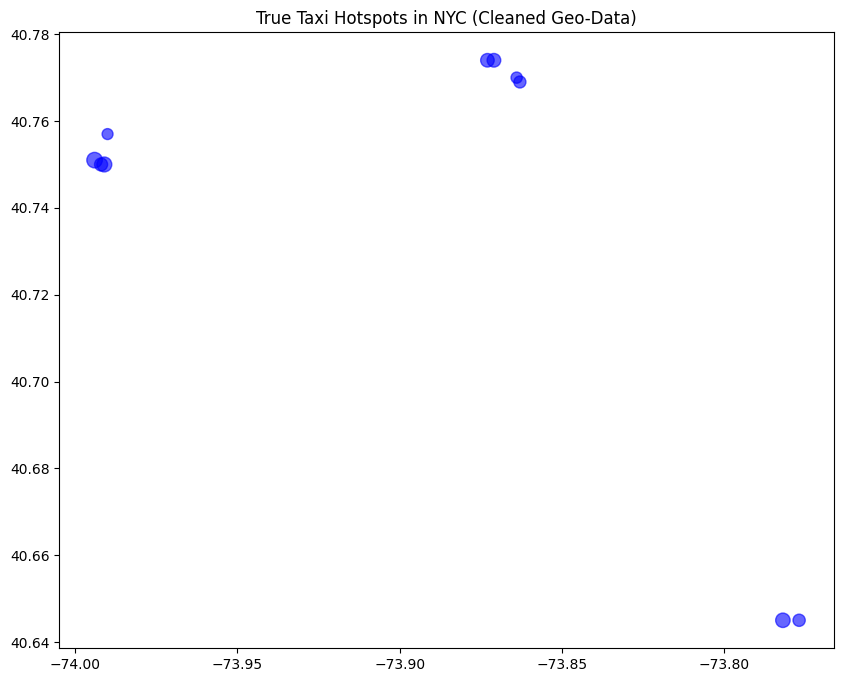

In [39]:

df_geo_cleaned = df_cleaned.filter(
    (col("pickup_longitude") > -75) & (col("pickup_longitude") < -73) &
    (col("pickup_latitude") > 40) & (col("pickup_latitude") < 42)
)

hotspots_final = df_geo_cleaned.groupBy(
    spark_round("pickup_longitude", 3).alias("long"),
    spark_round("pickup_latitude", 3).alias("lat")
).count().orderBy("count", ascending=False)

top_10_final = hotspots_final.limit(10).toPandas()

plt.figure(figsize=(10, 8))
plt.scatter(top_10_final['long'], top_10_final['lat'], 
            s=top_10_final['count']/500, alpha=0.6, c='blue')
plt.title("True Taxi Hotspots in NYC (Cleaned Geo-Data)")
plt.show()


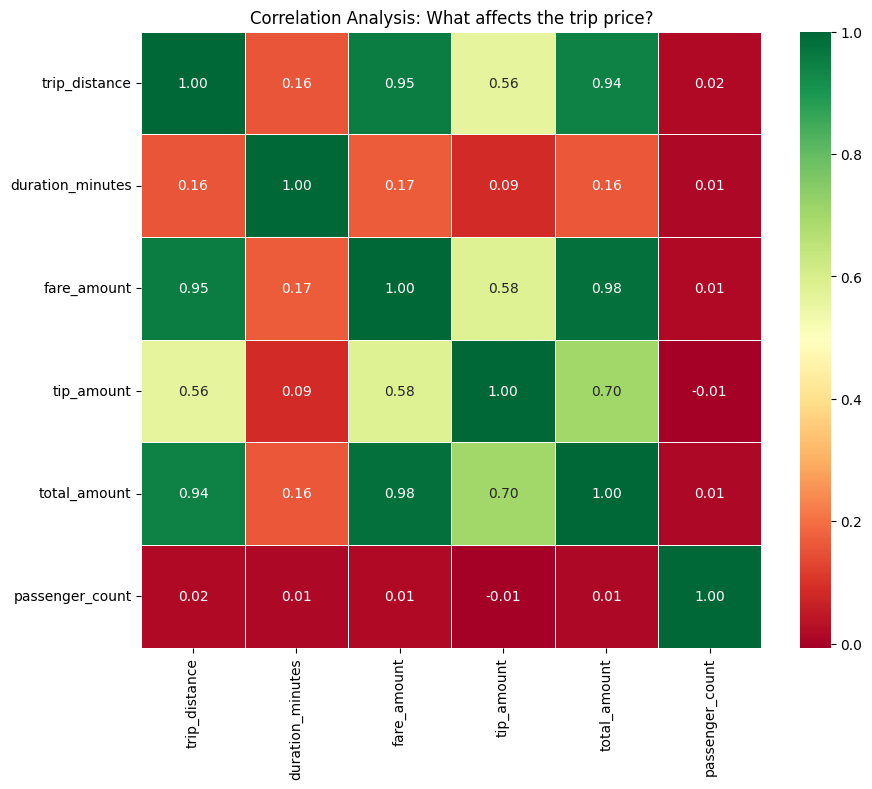

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_df = trip_type_tips.select(
    "trip_distance", "duration_minutes", "fare_amount", 
    "tip_amount", "total_amount", "passenger_count"
).sample(False, 0.01).toPandas()

corr = sample_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Correlation Analysis: What affects the trip price?")
plt.show()


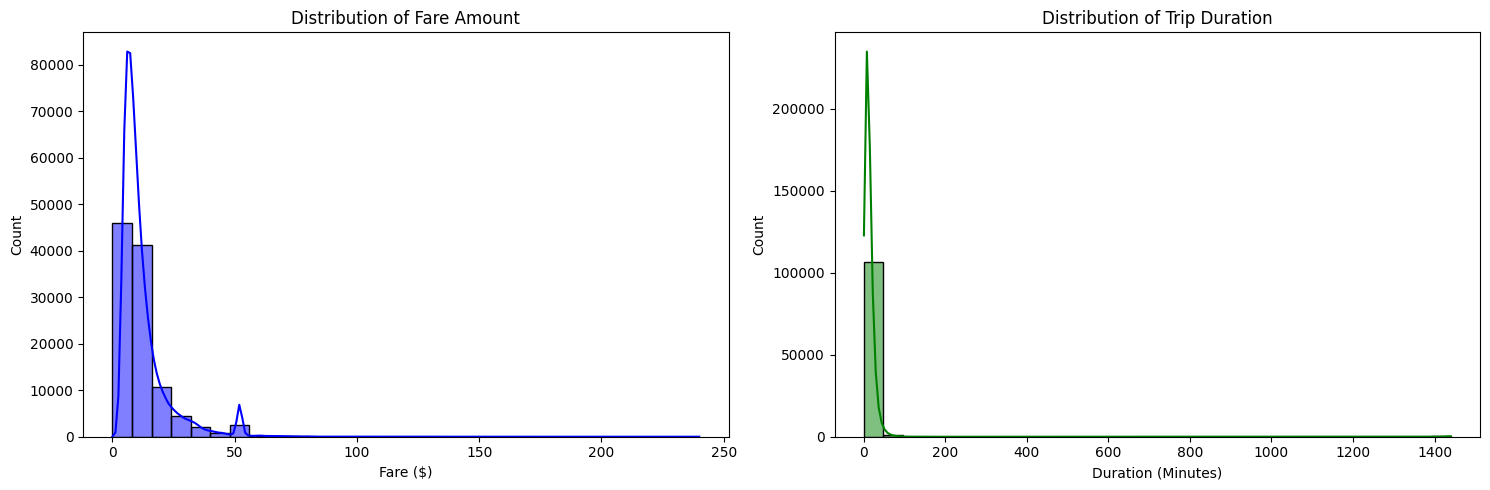

In [44]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(sample_df['fare_amount'], bins=30, kde=True, color='blue')
plt.title("Distribution of Fare Amount")
plt.xlabel("Fare ($)")

plt.subplot(1, 2, 2)
sns.histplot(sample_df['duration_minutes'], bins=30, kde=True, color='green')
plt.title("Distribution of Trip Duration")
plt.xlabel("Duration (Minutes)")

plt.tight_layout()
plt.show()
